Number of estimated clusters: 9


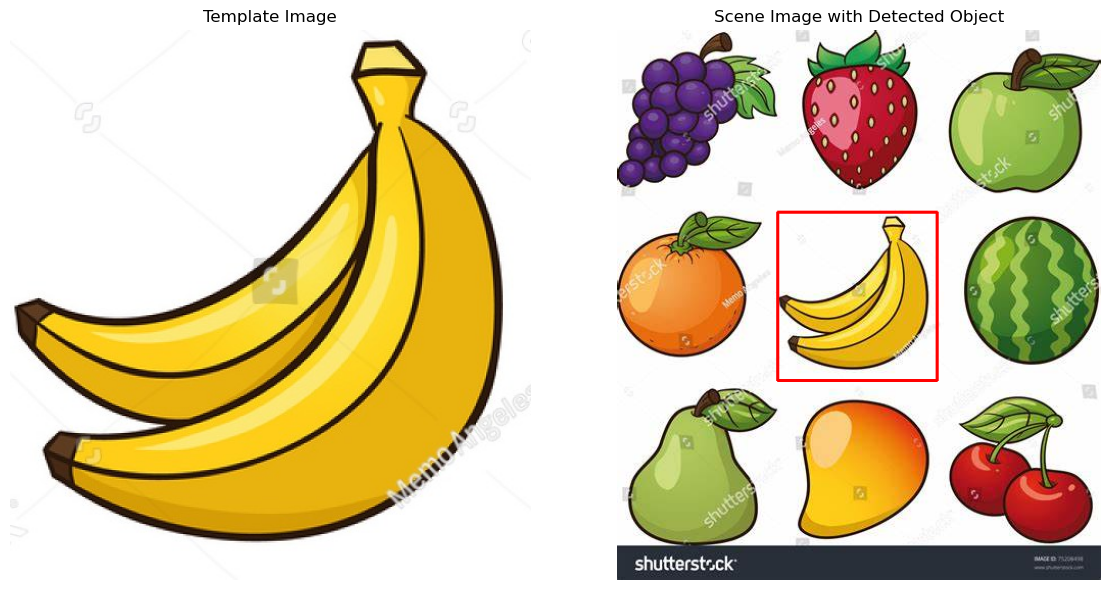

In [7]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth

MIN_MATCH_COUNT = 3

# Read images
img2 = cv2.imread("fruits.jpeg")  # Template image
img1 = cv2.imread("ban.jpeg")  # Scene image

if img1 is None or img2 is None:
    print("Error: One or both images not found!")
    exit()

# Convert img2 for drawing later
img_rgb = img2.copy()

# Initialize SIFT
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

if des1 is None or des2 is None:
    print("Error: No descriptors found in one or both images.")
    exit()

# Prepare data for clustering
x = np.array([kp.pt for kp in kp2])
if len(x) < 2:
    print("Not enough keypoints for clustering.")
    exit()

# Estimate bandwidth and apply MeanShift clustering
bandwidth = estimate_bandwidth(x, quantile=0.1, n_samples=len(x))
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=True)
ms.fit(x)
labels = ms.labels_
n_clusters_ = len(np.unique(labels))
print(f"Number of estimated clusters: {n_clusters_}")

# Group keypoints by cluster
clustered_kp = {i: [] for i in range(n_clusters_)}
for idx, label in enumerate(labels):
    clustered_kp[label].append(kp2[idx])

# FLANN matcher setup
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

des1 = np.float32(des1)
des2 = np.float32(des2)

for i in range(n_clusters_):
    kp2 = clustered_kp[i]
    if len(kp2) < 2 or len(kp1) < 2:
        continue

    d, = np.where(labels == i)
    des2_clustered = des2[d, :]
    matches = flann.knnMatch(des1, des2_clustered, k=2)
    good_matches = [m for m, n in matches if m.distance < 0.4 * n.distance]  # More strict ratio test

    if len(good_matches) > MIN_MATCH_COUNT:
        src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)  # Increased threshold for accuracy
        if M is None:
            print("No Homography found for cluster", i)
            continue

        # Draw bounding box
        h, w = img1.shape[:2]
        corners = np.float32([[0, 0], [0, h - 1], [w - 1, h - 1], [w - 1, 0]]).reshape(-1, 1, 2)
        transformed_corners = cv2.perspectiveTransform(corners, M)

        x_min = int(min(transformed_corners[:, 0, 0]))
        y_min = int(min(transformed_corners[:, 0, 1]))
        x_max = int(max(transformed_corners[:, 0, 0]))
        y_max = int(max(transformed_corners[:, 0, 1]))

        cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), (0, 0, 255), 2)  # Smaller bbox

# Convert images for matplotlib
img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

# Plot using matplotlib
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.title('Template Image')
plt.axis('off')
plt.imshow(img1_rgb)

plt.subplot(122)
plt.title('Scene Image with Detected Object')
plt.axis('off')
plt.imshow(img_rgb)

plt.tight_layout()
plt.show()